# IS 310 - 2023 Spotify Dataset Final

My code + visualizations for the project!!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load in the 2023 dataset

In [3]:
original = pd.read_csv('spotify-2023.csv', encoding="latin1") #latin1 for special characters
original.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [4]:
original.shape

(953, 24)

**Visual 1: Most popular artists**

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Taylor Swift'),
  Text(1, 0, 'The Weeknd'),
  Text(2, 0, 'Bad Bunny'),
  Text(3, 0, 'SZA'),
  Text(4, 0, 'Harry Styles'),
  Text(5, 0, 'Kendrick Lamar'),
  Text(6, 0, 'Morgan Wallen'),
  Text(7, 0, 'Ed Sheeran'),
  Text(8, 0, 'BTS'),
  Text(9, 0, 'Feid'),
  Text(10, 0, 'Drake, 21 Savage'),
  Text(11, 0, 'Labrinth'),
  Text(12, 0, 'Olivia Rodrigo'),
  Text(13, 0, 'NewJeans'),
  Text(14, 0, 'Doja Cat')])

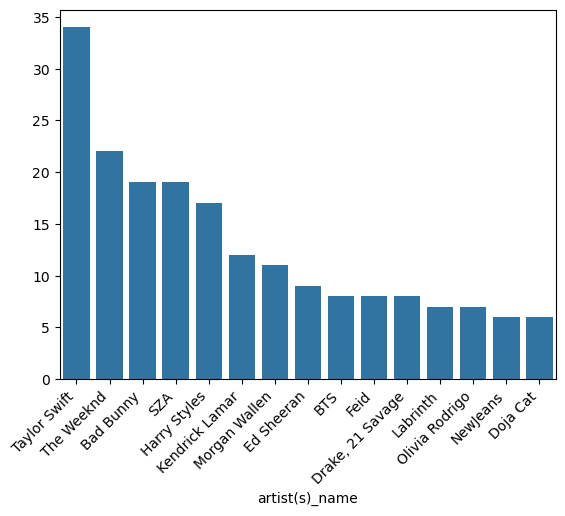

In [5]:
artist_counts = original["artist(s)_name"].value_counts().head(15)
sns.barplot(x=artist_counts.index, y=artist_counts.values)
plt.xticks(rotation=45, ha="right")

**Visual 2: Distribution of Streams**

<Axes: ylabel='Frequency'>

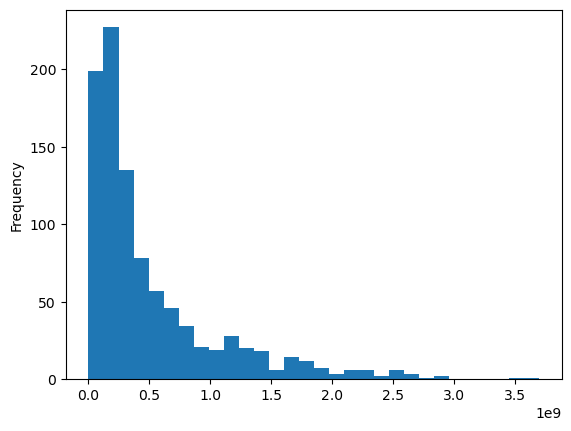

In [6]:
original["streams"] = (original["streams"].astype(str).str.replace(",", "", regex=False))
original["streams"] = pd.to_numeric(original["streams"], errors="coerce")
original["streams"].plot.hist(bins=30)

**Visual 3: Danceability vs Streams**

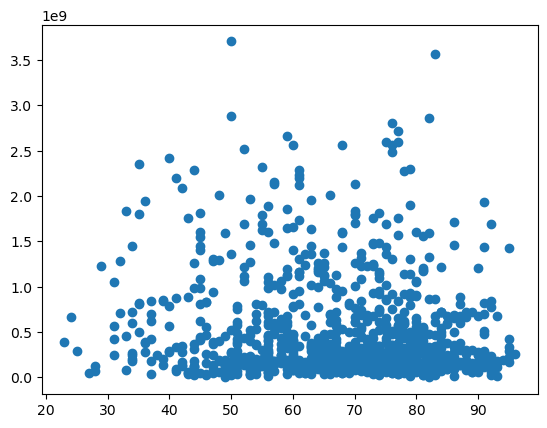

In [7]:
plt.scatter(original['danceability_%'], original['streams'])

**Initial Dataset Submission - 75 Songs**

In [8]:
sample_75 = original.sample(n=75, random_state=42)
sample_75.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
199,Take On Me,a-ha,1,1984,10,19,44927,17,1.479115e+09,34,...,84,F#,Minor,57,86,90,2,0,9,5
420,Rumble,"Skrillex, Flowdan, Fred again..",3,2022,1,17,2849,0,7.848982e+07,39,...,140,C#,Minor,81,6,84,5,23,6,6
694,NEW MAGIC WAND,"Tyler, The Creator",2,2019,5,16,4708,0,4.614378e+08,13,...,140,F,Minor,62,46,73,10,0,67,11
750,Falling,Harry Styles,1,2019,12,13,7556,0,1.023187e+09,124,...,110,E,Major,57,6,27,84,0,9,3
507,Pepas,Farruko,1,2021,6,24,14114,17,1.309887e+09,252,...,130,G,Major,76,44,77,1,0,13,3


In [9]:
sample_75.shape

(75, 24)

In [11]:
sample_75[["streams", "danceability_%", "valence_%", "energy_%", "bpm"]].describe()

,streams,danceability_%,valence_%,energy_%,bpm
count,7.500000e+01,75.000000,75.000000,75.000000,75.000000
mean,5.231753e+08,66.906667,49.373333,63.293333,126.320000
std,5.940104e+08,13.650238,23.944628,18.557998,27.476358
min,2.258116e+07,33.000000,6.000000,26.000000,65.000000
25%,1.449685e+08,57.500000,29.000000,48.500000,106.500000
50%,3.384220e+08,70.000000,48.000000,64.000000,126.000000
75%,5.917191e+08,79.000000,68.500000,78.500000,141.000000
max,2.887242e+09,87.000000,96.000000,94.000000,198.000000


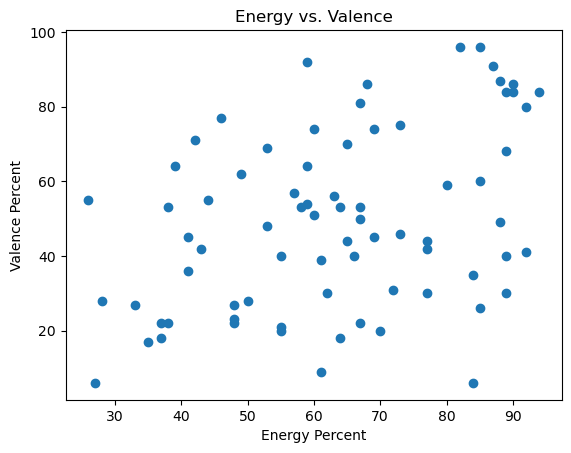

In [14]:
plt.scatter(sample_75["energy_%"], sample_75["valence_%"])
plt.title("Energy vs. Valence")
plt.xlabel("Energy Percent")
plt.ylabel("Valence Percent")
plt.show()

In [18]:
mixed_signal_songs = sample_75[(sample_75["danceability_%"] > 70) & (sample_75["valence_%"] < 40)]
mixed_signal_songs[["track_name", "artist(s)_name", "danceability_%", "valence_%", "energy_%"]]

,track_name,artist(s)_name,danceability_%,valence_%,energy_%
420,Rumble,"Skrillex, Flowdan, Fred again..",81,6,84
928,California Breeze,Lil Baby,74,22,67
939,Spin Bout U,"Drake, 21 Savage",77,20,70
30,Rush,Troye Sivan,74,35,84
589,Praise God,Kanye West,80,21,55
198,Ditto,NewJeans,81,18,64
787,ULTRA SOLO,"Polima WestCoast, Pailita",80,26,85
752,Fim de Semana no Rio,teto,87,28,50
572,Knife Talk (with 21 Savage ft. Project Pat),"Drake, Project Pat, 21 Savage",85,22,37


**Final 500 Song Dataset**

Based on feedback from professor about actually looking into cultural influence (proper auditing)

In [ ]:
sample75 = original.sample(n=75, random_state=42).copy()
sample75.to_csv("inika_initial_75_sample.csv", index=False)
print(sample75.shape)
sample75.head()

(75, 24)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
199,Take On Me,a-ha,1,1984,10,19,44927,17,1.479115e+09,34,...,84,F#,Minor,57,86,90,2,0,9,5
420,Rumble,"Skrillex, Flowdan, Fred again..",3,2022,1,17,2849,0,7.848982e+07,39,...,140,C#,Minor,81,6,84,5,23,6,6
694,NEW MAGIC WAND,"Tyler, The Creator",2,2019,5,16,4708,0,4.614378e+08,13,...,140,F,Minor,62,46,73,10,0,67,11
750,Falling,Harry Styles,1,2019,12,13,7556,0,1.023187e+09,124,...,110,E,Major,57,6,27,84,0,9,3
507,Pepas,Farruko,1,2021,6,24,14114,17,1.309887e+09,252,...,130,G,Major,76,44,77,1,0,13,3


In [25]:
#clean
numeric_cols = [
    "artist_count",
    "released_year",
    "released_month",
    "released_day",
    "in_spotify_playlists",
    "in_spotify_charts",
    "streams",
    "in_apple_playlists",
    "in_apple_charts",
    "in_deezer_playlists",
    "in_deezer_charts",
    "in_shazam_charts",
    "bpm",
    "danceability_%",
    "valence_%",
    "energy_%",
    "acousticness_%",
    "instrumentalness_%",
    "liveness_%",
    "speechiness_%"]

for col in numeric_cols:
    if col in original.columns:
        original[col] = (original[col].astype(str).str.replace(",", "", regex=False).str.extract(r"([-+]?\d*\.?\d+)")[0])
        original[col] = pd.to_numeric(original[col], errors="coerce")

for col in numeric_cols:
    if col in sample_75.columns:
        sample_75[col] = (sample_75[col].astype(str).str.replace(",", "", regex=False).str.extract(r"([-+]?\d*\.?\d+)")[0])
        sample_75[col] = pd.to_numeric(sample_75[col], errors="coerce")

Manually inputting my ideas on the labels for the first 10 songs

In [31]:
manual_labels = {
    0: "mixed emotional tone",
    1: "upbeat pop anthem",
    2: "dance-focused track",
    3: "emotionally tense",
    4: "mixed emotional tone",
    5: "reflective acoustic mood",
    6: "danceable but emotionally negative",
    7: "emotionally positive",
    8: "mixed emotional tone",
    9: "somber mood"}

sample_75 = sample_75.reset_index(drop=True)
sample_75["interpreted_song_type"] = sample_75.index.map(manual_labels)
sample_75[["track_name", "artist(s)_name", "danceability_%", "energy_%", "valence_%", "interpreted_song_type"]]

,track_name,artist(s)_name,danceability_%,energy_%,valence_%,interpreted_song_type
0,Take On Me,a-ha,57,90,86,mixed emotional tone
1,Rumble,"Skrillex, Flowdan, Fred again..",81,84,6,upbeat pop anthem
2,NEW MAGIC WAND,"Tyler, The Creator",62,73,46,dance-focused track
3,Falling,Harry Styles,57,27,6,emotionally tense
4,Pepas,Farruko,76,77,44,mixed emotional tone
...,...,...,...,...,...,...
70,Nostï¿½ï¿½l,"Chris Brown, Rvssian, Rauw Alejandro",73,85,60,NaN
71,Love Language,SZA,71,26,55,NaN
72,Makeba,Jain,82,66,40,NaN
73,Love Yourself,Justin Bieber,61,38,53,NaN


Automating this for remaining rows

In [48]:
def interpreted_song_type(row):
    energy = row["energy_%"]
    valence = row["valence_%"]
    danceability = row["danceability_%"]
    acousticness = row["acousticness_%"]

    if energy > 80 and valence > 70:
        return "upbeat pop anthem"
    elif danceability > 70 and valence < 40:
        return "danceable but emotionally negative"
    elif energy > 80 and valence < 35:
        return "emotionally tense"
    elif danceability > 75:
        return "dance-focused track"
    elif valence > 70:
        return "emotionally positive"
    elif valence < 30:
        return "somber mood"
    else:
        return "mixed emotional tone"
    
sample_75["interpreted_song_type"] = sample_75.apply(interpreted_song_type, axis=1)
sample_75[["track_name", "artist(s)_name", "danceability_%", "energy_%", "valence_%", "interpreted_song_type"]].head(15)    

,track_name,artist(s)_name,danceability_%,energy_%,valence_%,interpreted_song_type
0,Take On Me,a-ha,57,90,86,upbeat pop anthem
1,Rumble,"Skrillex, Flowdan, Fred again..",81,84,6,danceable but emotionally negative
2,NEW MAGIC WAND,"Tyler, The Creator",62,73,46,mixed emotional tone
3,Falling,Harry Styles,57,27,6,somber mood
4,Pepas,Farruko,76,77,44,dance-focused track
5,Arcade,Duncan Laurence,45,33,27,somber mood
6,Yet To Come,BTS,56,89,68,mixed emotional tone
7,MONEY,Lisa,83,55,40,dance-focused track
8,California Breeze,Lil Baby,74,67,22,danceable but emotionally negative
9,ýýýýýýýýýýýý,YOASOBI,57,94,84,upbeat pop anthem


Labelled Songs Visualization

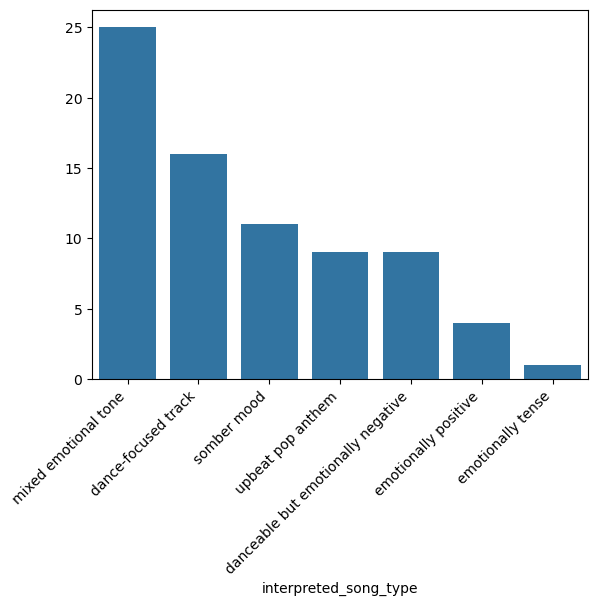

In [40]:
song_type_counts = sample_75["interpreted_song_type"].value_counts().head(15)
sns.barplot(x=song_type_counts.index, y=song_type_counts.values)
plt.xticks(rotation=45, ha="right")
plt.show()

Shows that mixed tones in music are common...time to create the final 500 song dataset

**Final Dataset**

In [ ]:
final = original.head(500).copy()

for col in numeric_cols:
    if col in final.columns:
        final[col] = final[col].fillna(final[col].median())
print(final.shape)

(500, 24)


In [57]:
#add popularity
final["popularity_score"] = (
    final["in_spotify_playlists"] * 0.30 +
    final["in_spotify_charts"] * 0.25 +
    final["in_apple_charts"] * 0.15 +
    final["in_deezer_charts"] * 0.10 +
    final["in_shazam_charts"] * 0.20)
final.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_score,spotify_mood_label,interpreted_song_type,mood_complexity,platform_visibility_type
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,83,31,0,8,4,408.30,upbeat,upbeat pop anthem,simple,playlist-driven
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,74,7,0,10,4,550.90,mixed,mixed emotional tone,complex,playlist-driven
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,53,17,0,31,6,669.60,mixed,mixed emotional tone,complex,playlist-driven
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,72,11,0,11,15,2524.25,mixed,mixed emotional tone,complex,playlist-driven
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,80,14,63,11,6,1058.85,mixed,somber mood,complex,playlist-driven


In [ ]:
#add mood label
def spotify_mood_label(row):
    energy = row["energy_%"]
    valence = row["valence_%"]
    if valence > 70 and energy > 70:
        return "upbeat"
    elif valence < 35 and energy < 50:
        return "sad"
    elif energy > 80:
        return "intense"
    elif valence > 65:
        return "positive"
    else:
        return "mixed"
final["spotify_mood_label"] = final.apply(spotify_mood_label, axis=1)
final.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_score,spotify_mood_label,interpreted_song_type,mood_complexity,platform_visibility_type
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,83,31,0,8,4,408.30,upbeat,upbeat pop anthem,simple,playlist-driven
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,74,7,0,10,4,550.90,mixed,mixed emotional tone,complex,playlist-driven
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,53,17,0,31,6,669.60,mixed,mixed emotional tone,complex,playlist-driven
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,72,11,0,11,15,2524.25,mixed,mixed emotional tone,complex,playlist-driven
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,80,14,63,11,6,1058.85,mixed,somber mood,complex,playlist-driven


In [55]:
#add interpreted song type label
final["interpreted_song_type"] = final.apply(interpreted_song_type, axis=1)
final.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_score,spotify_mood_label,interpreted_song_type,mood_complexity,platform_visibility_type
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,83,31,0,8,4,408.30,upbeat,upbeat pop anthem,simple,playlist-driven
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,74,7,0,10,4,550.90,mixed,mixed emotional tone,complex,playlist-driven
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,53,17,0,31,6,669.60,mixed,mixed emotional tone,complex,playlist-driven
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,72,11,0,11,15,2524.25,mixed,mixed emotional tone,complex,playlist-driven
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,80,14,63,11,6,1058.85,mixed,somber mood,complex,playlist-driven


In [54]:
#mood complexity
def mood_complexity(row):
    spotify = row["spotify_mood_label"]
    interpreted = row["interpreted_song_type"]
    if (
        ("negative" in interpreted or "somber" in interpreted or "tense" in interpreted)
        and spotify in ["upbeat", "positive"]
    ):
        return "contradictory"

    elif spotify == "mixed" or "mixed" in interpreted:
        return "complex"

    else:
        return "simple"
final["mood_complexity"] = final.apply(mood_complexity, axis=1)
final.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_score,spotify_mood_label,interpreted_song_type,mood_complexity,platform_visibility_type
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,83,31,0,8,4,408.30,upbeat,upbeat pop anthem,simple,playlist-driven
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,74,7,0,10,4,550.90,mixed,mixed emotional tone,complex,playlist-driven
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,53,17,0,31,6,669.60,mixed,mixed emotional tone,complex,playlist-driven
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,72,11,0,11,15,2524.25,mixed,mixed emotional tone,complex,playlist-driven
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,80,14,63,11,6,1058.85,mixed,somber mood,complex,playlist-driven


In [53]:
#platform visibility type
def platform_visibility_type(row):
    if row["in_spotify_playlists"] > 200:
        return "playlist-driven"
    elif row["in_spotify_charts"] > 75:
        return "chart-driven"
    elif row["in_shazam_charts"] > 100:
        return "viral/social-media-driven"
    else:
        return "cross-platform-balanced"
final["platform_visibility_type"] = final.apply(platform_visibility_type, axis=1)
final.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_score,spotify_mood_label,interpreted_song_type,mood_complexity,platform_visibility_type
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,83,31,0,8,4,408.30,upbeat,upbeat pop anthem,simple,playlist-driven
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,74,7,0,10,4,550.90,mixed,mixed emotional tone,complex,playlist-driven
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,53,17,0,31,6,669.60,mixed,mixed emotional tone,complex,playlist-driven
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,72,11,0,11,15,2524.25,mixed,mixed emotional tone,complex,playlist-driven
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,80,14,63,11,6,1058.85,mixed,somber mood,complex,playlist-driven


In [59]:
#audit note
def audit_note(row):
    if row["energy_%"] > 80 and row["valence_%"] < 35:
        return "high energy despite low emotional positivity"
    elif row["danceability_%"] > 75 and row["valence_%"] < 40:
        return "danceability conflicts with emotional tone"
    elif row["mood_complexity"] == "contradictory":
        return "spotify metrics flatten emotional complexity"
    elif row["mood_complexity"] == "complex":
        return "mixed emotional signals across metrics"
    else:
        return "spotify and interpretive labels mostly align"
final["audit_note"] = final.apply(audit_note, axis=1)
final.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,popularity_score,spotify_mood_label,interpreted_song_type,mood_complexity,platform_visibility_type,audit_note
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,31,0,8,4,408.30,upbeat,upbeat pop anthem,simple,playlist-driven,spotify and interpretive labels mostly align
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,7,0,10,4,550.90,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,17,0,31,6,669.60,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,11,0,11,15,2524.25,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,14,63,11,6,1058.85,mixed,somber mood,complex,playlist-driven,mixed emotional signals across metrics


In [61]:
#external visibility factor (professor feedback)
def external_visibility_factor(row):
    if row["in_shazam_charts"] > 100:
        return "social media virality"
    elif row["in_spotify_playlists"] > 250:
        return "playlist amplification"
    elif row["in_spotify_charts"] > 75:
        return "platform chart momentum"
    elif row["artist_count"] > 2:
        return "collaborative artist visibility"
    else:
        return "mixed or unclear visibility"
final["external_visibility_factor"] = final.apply(external_visibility_factor, axis=1)
final

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,instrumentalness_%,liveness_%,speechiness_%,popularity_score,spotify_mood_label,interpreted_song_type,mood_complexity,platform_visibility_type,audit_note,external_visibility_factor
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,0,8,4,408.30,upbeat,upbeat pop anthem,simple,playlist-driven,spotify and interpretive labels mostly align,social media virality
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,0,10,4,550.90,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics,social media virality
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,0,31,6,669.60,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics,social media virality
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,0,11,15,2524.25,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics,social media virality
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,63,11,6,1058.85,mixed,somber mood,complex,playlist-driven,mixed emotional signals across metrics,social media virality
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Run Rudolph Run - Single Version,Chuck Berry,1,1958,1,1,8612,0,245350949.0,120,...,0,7,8,2588.30,upbeat,emotionally positive,simple,playlist-driven,spotify and interpretive labels mostly align,playlist amplification
496,Jingle Bells - Remastered 1999,Frank Sinatra,1,1957,1,1,4326,0,178660459.0,32,...,0,10,5,1298.25,positive,emotionally positive,simple,playlist-driven,spotify and interpretive labels mostly align,playlist amplification
497,Far,SZA,1,2022,12,9,680,0,51641685.0,2,...,0,16,8,206.25,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics,playlist amplification
498,On Time (with John Legend),"John Legend, Metro Boomin",2,2022,12,2,398,0,78139948.0,2,...,0,44,6,120.10,mixed,mixed emotional tone,complex,playlist-driven,mixed emotional signals across metrics,playlist amplification


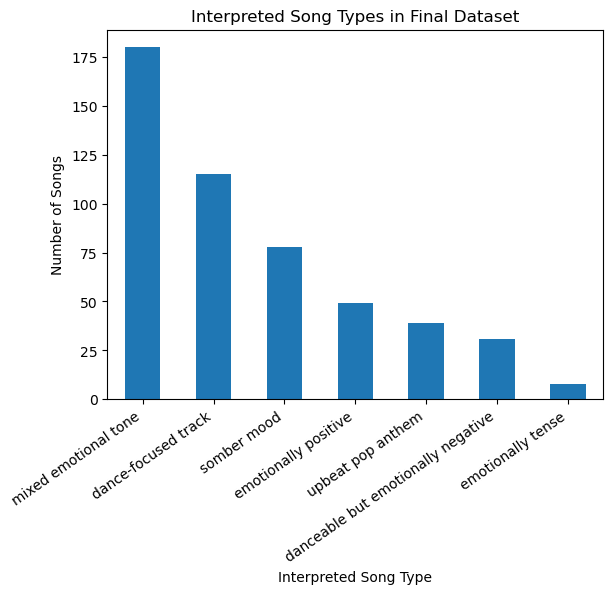

In [ ]:
final["interpreted_song_type"].value_counts().plot(kind="bar")
plt.title("Interpreted Song Types in Final Dataset")
plt.xlabel("Interpreted Song Type")
plt.ylabel("Number of Songs")
plt.xticks(rotation=35, ha="right")
plt.show()

broken down into multiple song types

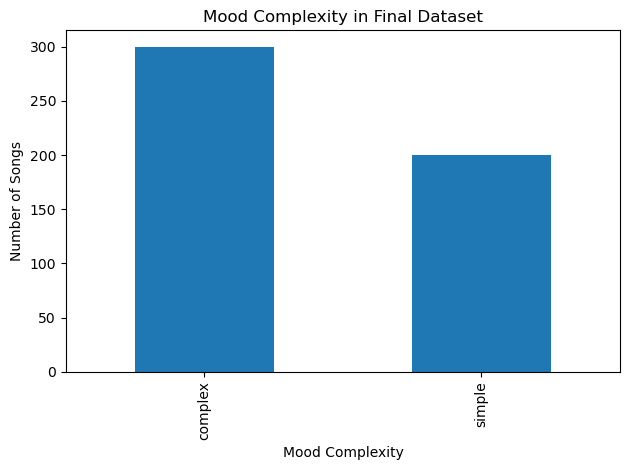

In [ ]:
final["mood_complexity"].value_counts().plot(kind="bar")
plt.title("Mood Complexity in Final Dataset")
plt.xlabel("Mood Complexity")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

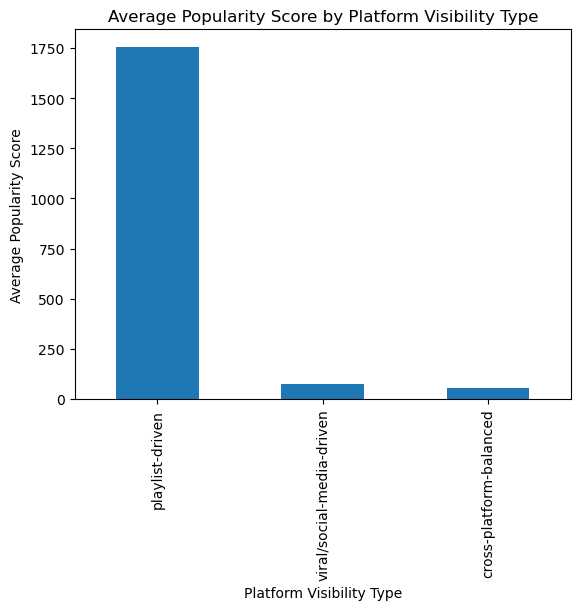

In [70]:
avg_popularity = (final.groupby("platform_visibility_type")["popularity_score"].mean().sort_values(ascending=False))
avg_popularity.plot(kind="bar")
plt.title("Average Popularity Score by Platform Visibility Type")
plt.xlabel("Platform Visibility Type")
plt.ylabel("Average Popularity Score")
plt.show()

In this scenario, most of the songs became popular through ending up in multiple playlists. This has big cultural implications.

**CONCLUSION**

This project began as an attempt to understand what makes songs popular using Spotify metrics such as danceability, energy, and valence. However, as I worked with the data, I realized that these metrics aren't really objective measurements but instead computational interpretations that Spotify's ML systems made. By expanding the dataset, I was able to explore how platforms classify mood, popularity,  visibility etc. while also seeing how scales reduces emotional and cultural nuance. Overall, this project showed me that studying music as data requires analyzing not only songs themselves, but also the systems that make them visible and numeric.

Thank you again Professor for all of your feedback throughout the semester, it significantly improved  the direction of this project. It also completely transformed the depth in the way I think about culture as data!